### Imports

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import scipy

### Functions

In [2]:
def process_results(path, aggregation_function = np.mean):

    with open(path, 'r') as file:
        data = json.load(file)

    distances = {}
    returns = {}

    for run_number in data:

        run_results = data[run_number]

        return_results = []
        distance_results = []

        for noise_level in run_results:
            
            noise_results = run_results[noise_level]
            
            mean_return = aggregation_function(noise_results["cumulative_reward"])
            mean_distance = aggregation_function(noise_results["distance"])

            return_results.append(mean_return)
            distance_results.append(mean_distance)

        returns[run_number] = return_results
        distances[run_number] = distance_results
            
    return distances, returns

In [3]:
def plot_data(dicts):
    return [item[0] for item in dicts[0].values()], [item[0] for item in dicts[1].values()]

In [4]:
def make_graph(matrix, capsize=8):
    # plt.figure(figsize=(10, 6))

    # values = np.array(list(matrix.values()))
    # x = list(matrix.keys())

    # # Median
    # medians = np.median(values, axis=1)

    # # IQR
    # q1 = np.quantile(values, 0.25, axis=1)
    # q3 = np.quantile(values, 0.75, axis=1)

    # lower_errors = medians - q1
    # upper_errors = q3 - medians

    # yerr = np.vstack([lower_errors, upper_errors])

    # # Plot with caps
    # plt.errorbar(x, medians, yerr=yerr, fmt='o', capsize=capsize, ecolor='black', markerfacecolor='blue')

    plt.figure(figsize=(4,3))
    plt.boxplot(matrix, vert=False)

### Hopper Task

In [5]:
base_hopper_distances, base_hopper_returns = plot_data(process_results("../results/no_noise/nonoise_base_agent_Hopper-v5.json"))
baseppo_hopper_distances, baseppo_hopper_returns = plot_data(process_results("../results/no_noise/nonoise_baseppo_agent_Hopper-v5.json"))
state_hopper_distances, state_hopper_returns = plot_data(process_results("../results/no_noise/nonoise_state_agent_Hopper-v5.json"))
stateppo_hopper_distances, stateppo_hopper_returns = plot_data(process_results("../results/no_noise/nonoise_stateppo_agent_Hopper-v5.json"))
action_hopper_distances, action_hopper_returns = plot_data(process_results("../results/no_noise/nonoise_action_agent_Hopper-v5.json"))
# actionppo_hopper_distances, actionppo_hopper_returns = plot_data(process_results("../results/no_noise/nonoise_actionppo_agent_Hopper-v5.json"))
transition_hopper_distances, transition_hopper_returns = plot_data(process_results("../results/no_noise/nonoise_transition_agent_Hopper-v5.json"))

In [6]:
hopper_distances_matrix = {
    "base": base_hopper_distances,
    "state": state_hopper_distances,
    "action": action_hopper_distances,
    "baseppo": baseppo_hopper_distances,
    "transition": transition_hopper_distances,
    "stateppo": stateppo_hopper_distances,
    # "actionppo": actionppo_hopper_distances
    }

hopper_returns_matrix = {
    "base": base_hopper_returns,
    "state": state_hopper_returns,
    "action": action_hopper_returns,
    "baseppo": baseppo_hopper_returns,
    "transition": transition_hopper_returns,
    "stateppo": stateppo_hopper_returns,
    # "actionppo": actionppo_hopper_returns
}

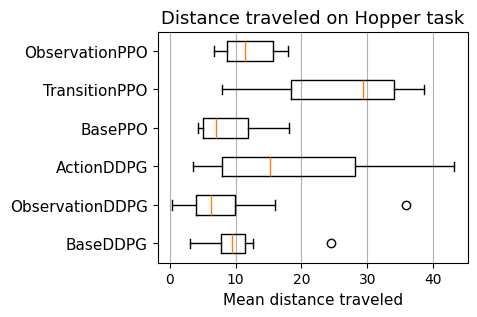

In [11]:
make_graph(list(hopper_distances_matrix.values()))
plt.title("Distance traveled on Hopper task", fontsize=13)
plt.xlabel("Mean distance traveled", fontsize=11)
plt.yticks([1,2,3,4,5,6], [
    "BaseDDPG", 
    "ObservationDDPG", 
    "ActionDDPG", 
    "BasePPO", 
    "TransitionPPO", 
    "ObservationPPO", 
    # "ActionPPO"
    ], ha="right", fontsize=11)
plt.grid(True, axis="x")

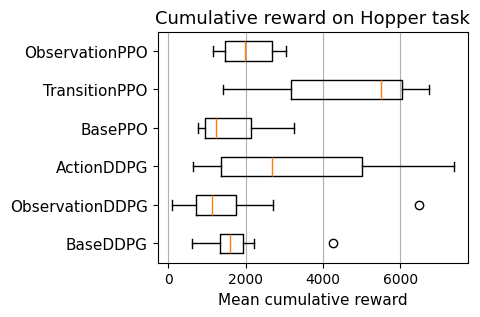

In [13]:
make_graph(list(hopper_returns_matrix.values()))
plt.title("Cumulative reward on Hopper task", fontsize=13)
plt.xlabel("Mean cumulative reward", fontsize=11)
plt.yticks([1,2,3,4,5,6], [
    "BaseDDPG", 
    "ObservationDDPG", 
    "ActionDDPG", 
    "BasePPO", 
    "TransitionPPO", 
    "ObservationPPO", 
    # "ActionPPO"
    ], ha="right", fontsize=11)
plt.grid(True, axis="x")

### Walker Task

In [14]:
base_walker_distances, base_walker_returns = plot_data(process_results("../results/no_noise/nonoise_base_agent_Walker2d-v5.json"))
baseppo_walker_distances, baseppo_walker_returns = plot_data(process_results("../results/no_noise/nonoise_baseppo_agent_Walker2d-v5.json"))
state_walker_distances, state_walker_returns = plot_data(process_results("../results/no_noise/nonoise_state_agent_Walker2d-v5.json"))
stateppo_walker_distances, stateppo_walker_returns = plot_data(process_results("../results/no_noise/nonoise_stateppo_agent_Walker2d-v5.json"))
action_walker_distances, action_walker_returns = plot_data(process_results("../results/no_noise/nonoise_action_agent_Walker2d-v5.json"))
# actionppo_walker_distances, actionppo_walker_returns = plot_data(process_results("../results/no_noise/nonoise_actionppo_agent_Walker2d-v5.json"))
transition_walker_distances, transition_walker_returns = plot_data(process_results("../results/no_noise/nonoise_transition_agent_Walker2d-v5.json"))

In [15]:
walker_distances_matrix = {
    "base": base_walker_distances,
    "state": state_walker_distances,
    "action": action_walker_distances,
    "baseppo": baseppo_walker_distances,
    "transition": transition_walker_distances,
    "stateppo": stateppo_walker_distances,
    # "actionppo": actionppo_walker_distances
}

walker_returns_matrix = {
    "base": base_walker_returns,
    "state": state_walker_returns,
    "action": action_walker_returns,
    "baseppo": baseppo_walker_returns,
    "transition": transition_walker_returns,
    "stateppo": stateppo_walker_returns,
    # "actionppo": actionppo_walker_returns
}

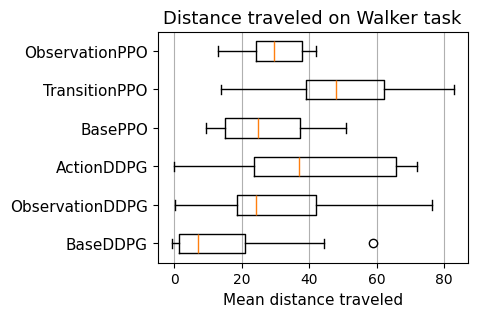

In [16]:
make_graph(list(walker_distances_matrix.values()))
plt.title("Distance traveled on Walker task", fontsize=13)
plt.xlabel("Mean distance traveled", fontsize=11)
plt.yticks([1,2,3,4,5,6], [
    "BaseDDPG", 
    "ObservationDDPG", 
    "ActionDDPG", 
    "BasePPO", 
    "TransitionPPO", 
    "ObservationPPO", 
    # "ActionPPO"
    ], ha="right", fontsize=11)
plt.grid(True, axis="x")

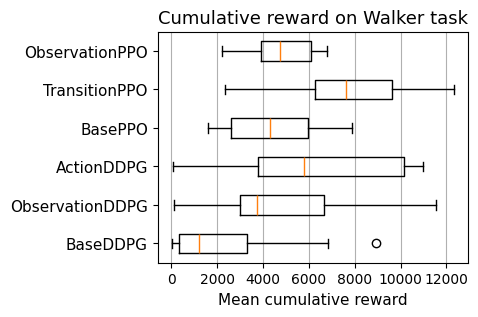

In [17]:
make_graph(list(walker_returns_matrix.values()))
plt.title("Cumulative reward on Walker task", fontsize=13)
plt.xlabel("Mean cumulative reward", fontsize=11)
plt.yticks([1,2,3,4,5,6], [
    "BaseDDPG", 
    "ObservationDDPG", 
    "ActionDDPG", 
    "BasePPO", 
    "TransitionPPO", 
    "ObservationPPO", 
    # "ActionPPO"
    ], ha="right", fontsize=11)
plt.grid(True, axis="x")

#### Distributions

In [41]:
def get_dist_data(path):
    # path = "../results/no_noise/nonoise_baseppo_agent_Hopper-v5.json"
    with open(path, 'r') as file:
        data = json.load(file)

    mean_reward_per_run = np.array([np.mean(data[run]["0.0"]["cumulative_reward"]) for run in data])
    mean_distance_per_run = np.array([np.mean(data[run]["0.0"]["distance"]) for run in data])

    return mean_reward_per_run, mean_distance_per_run

In [42]:
base_reward_dist, base_distance_dist_hopper = get_dist_data("../results/no_noise/nonoise_base_agent_Hopper-v5.json")
baseppo_reward_dist, baseppo_distance_dist_hopper = get_dist_data("../results/no_noise/nonoise_baseppo_agent_Hopper-v5.json")
state_reward_dist, state_distance_dist_hopper = get_dist_data("../results/no_noise/nonoise_state_agent_Hopper-v5.json")
stateppo_reward_dist, stateppo_distance_dist_hopper = get_dist_data("../results/no_noise/nonoise_stateppo_agent_Hopper-v5.json")
action_reward_dist, action_distance_dist_hopper = get_dist_data("../results/no_noise/nonoise_action_agent_Hopper-v5.json")
# actionppo_reward_dist, actionppo_distance_dist_hopper = get_dist_data("../results/no_noise/nonoise_actionppo_agent_Hopper-v5.json")
transition_reward_dist, transition_distance_dist_hopper = get_dist_data("../results/no_noise/nonoise_transition_agent_Hopper-v5.json")

In [43]:
baseddpg_distance_gof = scipy.stats.shapiro(base_distance_dist_hopper)
stateddpg_distance_gof = scipy.stats.shapiro(state_distance_dist_hopper)
actionddpg_distance_gof = scipy.stats.shapiro(action_distance_dist_hopper)
baseppo_distance_gof = scipy.stats.shapiro(baseppo_distance_dist_hopper)
stateppo_distance_gof = scipy.stats.shapiro(stateppo_distance_dist_hopper)
transitionppo_distance_gof = scipy.stats.shapiro(transition_distance_dist_hopper)

In [44]:
legend_labels_hopper = {
    "BaseDDPG": np.round(baseddpg_distance_gof.pvalue, 4),
    "ObservationDDPG": np.round(stateddpg_distance_gof.pvalue,4),
    "ActionDDPG": np.round(actionddpg_distance_gof.pvalue,4),
    "BasePPO": np.round(baseppo_distance_gof.pvalue,4),
    "ObservationPPO": np.round(stateppo_distance_gof.pvalue,4), 
    "TransitionPPO": np.round(transitionppo_distance_gof.pvalue,4) 
}

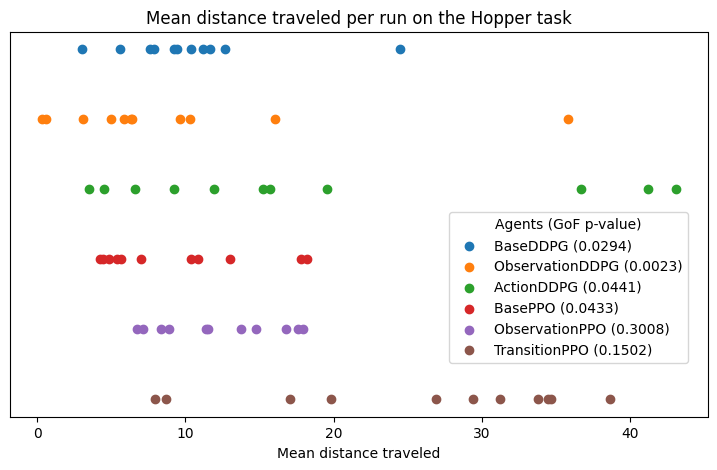

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(base_distance_dist_hopper, 11*[6], label=f"BaseDDPG ({legend_labels_hopper['BaseDDPG']})")
ax.scatter(state_distance_dist_hopper, 11*[5], label=f"ObservationDDPG ({legend_labels_hopper['ObservationDDPG']})")
ax.scatter(action_distance_dist_hopper, 11*[4], label=f"ActionDDPG ({legend_labels_hopper['ActionDDPG']})")
ax.scatter(baseppo_distance_dist_hopper, 11*[3], label=f"BasePPO ({legend_labels_hopper['BasePPO']})")
ax.scatter(stateppo_distance_dist_hopper, 11*[2], label=f"ObservationPPO ({legend_labels_hopper['ObservationPPO']})")
# plt.scatter(actionppo_distance_dist_hopper, 11*[6])
ax.scatter(transition_distance_dist_hopper, 11*[1], label=f"TransitionPPO ({legend_labels_hopper['TransitionPPO']})")

ax.set_title("Mean distance traveled per run on the Hopper task")
ax.set_xlabel("Mean distance traveled")
ax.tick_params(axis='y',which='both',left=False,labelleft=False)
ax.legend(title="Agents (GoF p-value)",loc='upper left', bbox_to_anchor=(0.62, 0.55))

In [46]:
base_reward_dist, base_distance_dist_walker = get_dist_data("../results/no_noise/nonoise_base_agent_Walker2d-v5.json")
baseppo_reward_dist, baseppo_distance_dist_walker = get_dist_data("../results/no_noise/nonoise_baseppo_agent_Walker2d-v5.json")
state_reward_dist, state_distance_dist_walker = get_dist_data("../results/no_noise/nonoise_state_agent_Walker2d-v5.json")
stateppo_reward_dist, stateppo_distance_dist_walker = get_dist_data("../results/no_noise/nonoise_stateppo_agent_Walker2d-v5.json")
action_reward_dist, action_distance_dist_walker = get_dist_data("../results/no_noise/nonoise_action_agent_Walker2d-v5.json")
# actionppo_reward_dist, actionppo_distance_dist_walker = get_dist_data("../results/no_noise/nonoise_actionppo_agent_Walker2d-v5.json")
transition_reward_dist, transition_distance_dist_walker = get_dist_data("../results/no_noise/nonoise_transition_agent_Walker2d-v5.json")

In [47]:
baseddpg_distance_gof = scipy.stats.shapiro(base_distance_dist_walker)
stateddpg_distance_gof = scipy.stats.shapiro(state_distance_dist_walker)
actionddpg_distance_gof = scipy.stats.shapiro(action_distance_dist_walker)
baseppo_distance_gof = scipy.stats.shapiro(baseppo_distance_dist_walker)
stateppo_distance_gof = scipy.stats.shapiro(stateppo_distance_dist_walker)
transitionppo_distance_gof = scipy.stats.shapiro(transition_distance_dist_walker)

In [48]:
legend_labels_walker = {
    "BaseDDPG": np.round(baseddpg_distance_gof.pvalue, 4),
    "ObservationDDPG": np.round(stateddpg_distance_gof.pvalue,4),
    "ActionDDPG": np.round(actionddpg_distance_gof.pvalue,4),
    "BasePPO": np.round(baseppo_distance_gof.pvalue,4),
    "ObservationPPO": np.round(stateppo_distance_gof.pvalue,4), 
    "TransitionPPO": np.round(transitionppo_distance_gof.pvalue,4) 
}

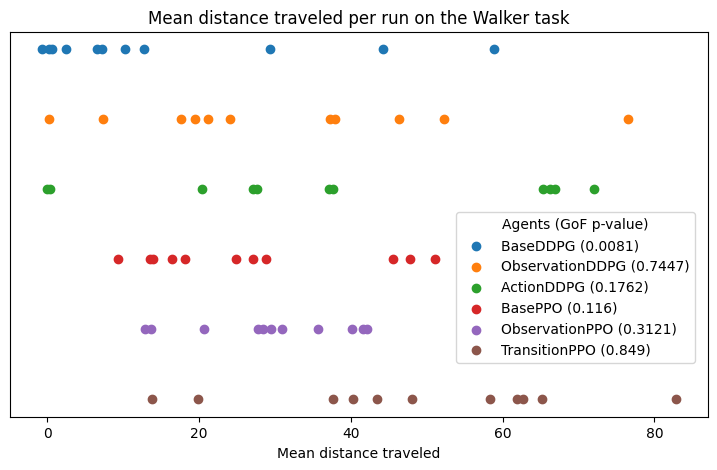

In [49]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(base_distance_dist_walker, 11*[6], label=f"BaseDDPG ({legend_labels_walker['BaseDDPG']})")
ax.scatter(state_distance_dist_walker, 11*[5], label=f"ObservationDDPG ({legend_labels_walker['ObservationDDPG']})")
ax.scatter(action_distance_dist_walker, 11*[4], label=f"ActionDDPG ({legend_labels_walker['ActionDDPG']})")
ax.scatter(baseppo_distance_dist_walker, 11*[3], label=f"BasePPO ({legend_labels_walker['BasePPO']})")
ax.scatter(stateppo_distance_dist_walker, 11*[2], label=f"ObservationPPO ({legend_labels_walker['ObservationPPO']})")
# plt.scatter(actionppo_distance_dist_hopper, 11*[6])
ax.scatter(transition_distance_dist_walker, 11*[1], label=f"TransitionPPO ({legend_labels_walker['TransitionPPO']})")

ax.set_title("Mean distance traveled per run on the Walker task")
ax.set_xlabel("Mean distance traveled")
ax.tick_params(axis='y',which='both',left=False,labelleft=False)
ax.legend(title="Agents (GoF p-value)",loc='upper left', bbox_to_anchor=(0.63, 0.55))